Analysis of the different model used

LINEAR REGRESSION (model 1):

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0,str(project_root))
print(sys.path[:3])


['/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction', '/opt/anaconda3/envs/air-quality/lib/python312.zip', '/opt/anaconda3/envs/air-quality/lib/python3.12']


In [2]:
import src

print(src)
print(src.__file__)

<module 'src' from '/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction/src/__init__.py'>
/Users/nathanchallande/Documents/ETHZ/portfolio/air-quality-prediction/src/__init__.py


In [3]:
from src.load_data import load_data
from src.preprocessing import X_train, X_validation, X_test, y_train, y_validation, y_test
from models.linear_regression import train_model, evaluate_model
import matplotlib.pyplot as plt
linear_model = train_model(X_train, y_train)
y_validation_pred = linear_model.predict(X_validation)
#to evaluate the model we will use 3 metrics: MAE, RMSE, and R2
mae, rmse, r2 = evaluate_model(linear_model, X_validation, y_validation)


In [4]:
print("Validation MAE:", mae)
print("Validation RMSE:", rmse)
print("Validation R²:", r2)
print(
    "Actual PM2.5 range:",
    y_validation.min(),
    "→",
    y_validation.max()
)

print(
    "Predicted PM2.5 range:",
    y_validation_pred.min(),
    "→",
    y_validation_pred.max()
)

Validation MAE: 41.09320701468777
Validation RMSE: 56.56348111665171
Validation R²: 0.35146995936551784
Actual PM2.5 range: 3.0 → 999.0
Predicted PM2.5 range: -110.06736543460806 → 250.39355571771762


we can see that linear regression isn't able to represent extreme pollution values. Also it diplays values negative which has no physical meaning.

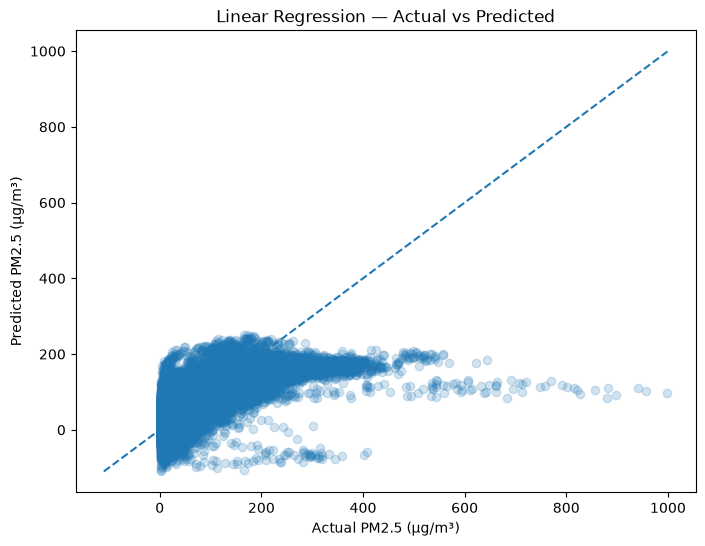

In [5]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation,
    y_validation_pred,
    alpha=0.2
)

min_value = min(
    y_validation.min(),
    y_validation_pred.min()
)

max_value = max(
    y_validation.max(),
    y_validation_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

LINEAR REGRESSION (model 2)

In [6]:
from src.preprocessing import X_train_pollution, X_validation_pollution, X_test_pollution, y_train_pollution, y_validation_pollution, y_test_pollution
linear_model_pollution = train_model(X_train_pollution, y_train_pollution)
y_validation_pollution_pred = linear_model_pollution.predict(X_validation_pollution)
mae_pollution, rmse_pollution, r2_pollution = evaluate_model(linear_model_pollution, X_validation_pollution, y_validation_pollution)

In [17]:
print("Validation MAE (Pollution):", mae_pollution)
print("Validation RMSE (Pollution):", rmse_pollution)
print("Validation R² (Pollution):", r2_pollution)
print(
    "Actual PM2.5 range:",
    y_validation_pollution.min(),
    "→",
    y_validation_pollution.max()
)
print(
    "Predicted PM2.5 range:",
    y_validation_pollution_pred.min(),
    "→",
    y_validation_pollution_pred.max()
)

Validation MAE (Pollution): 18.451862670719148
Validation RMSE (Pollution): 27.84380334172877
Validation R² (Pollution): 0.8388459962774704
Actual PM2.5 range: 3.0 → 821.0
Predicted PM2.5 range: -54.54330427706759 → 542.5041246882179


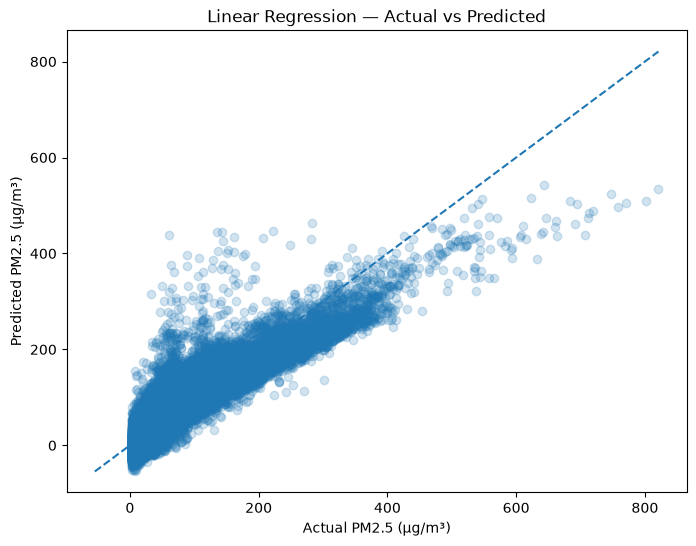

In [7]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_validation_pollution,
    y_validation_pollution_pred,
    alpha=0.2
)

min_value = min(
    y_validation_pollution.min(),
    y_validation_pollution_pred.min()
)

max_value = max(
    y_validation_pollution.max(),
    y_validation_pollution_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

Controlled comparison of the 2 model on the same restrictive data set (the one of model 2)

In [10]:
from src.preprocessing import X_train_common, X_validation_common, y_train_common, y_validation_common, X_train_common_pollution, X_validation_common_pollution, y_train_common_pollution, y_validation_common_pollution
linear_weather_common = train_model(X_train_common,y_train_common)
y_weather_validation = linear_weather_common.predict(X_validation_common)
mae_weather_common,rmse_weather_common,r2_weather_common = evaluate_model(linear_weather_common,X_validation_common,y_validation_common)

In [23]:
print("Weather-only model:")
print("MAE:", mae_weather_common)
print("RMSE:", rmse_weather_common)
print("R²:", r2_weather_common)
print((
    "Predicted PM2.5 range:",
    y_weather_validation.min(),
    "→",
    y_weather_validation.max()
))

Weather-only model:
MAE: 40.67222007775052
RMSE: 54.92028957203642
R²: 0.37302587063127823
('Predicted PM2.5 range:', np.float64(-108.89566815830335), '→', np.float64(248.4766189265613))


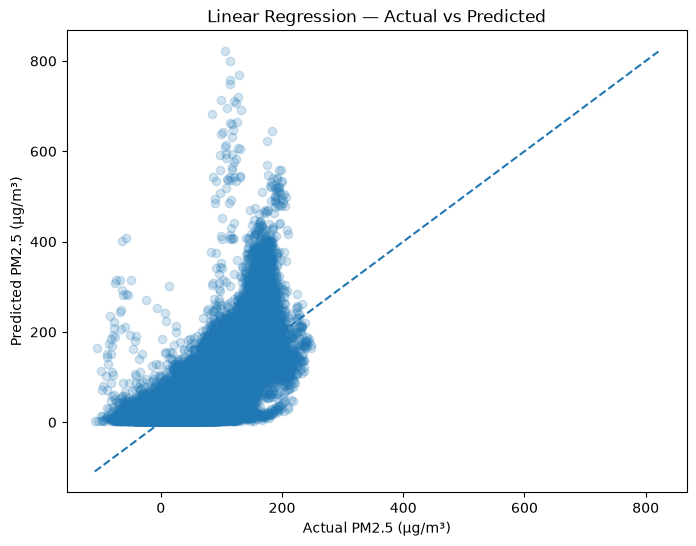

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_weather_validation,
    y_validation_common,
    alpha=0.2
)

min_value = min(
    y_weather_validation.min(),
    y_validation_common.min()
)

max_value = max(
    y_weather_validation.max(),
    y_validation_common.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

In [19]:
linear_pollution_model = train_model(X_train_common_pollution,y_train_common_pollution)
y_pollution_validation_pred = linear_pollution_model.predict(X_validation_common_pollution)
mae_pollution_common,rmse_pollution_common,r2_pollution_common = evaluate_model(linear_pollution_model,X_validation_common_pollution,y_validation_common_pollution)

In [22]:
print("Weather-pollution model:")
print("MAE:", mae_pollution_common)
print("RMSE:", rmse_pollution_common)
print("R²:", r2_pollution_common)
print((
    "Predicted PM2.5 range:",
    y_pollution_validation_pred.min(),
    "→",
    y_pollution_validation_pred.max()
))

Weather-pollution model:
MAE: 18.451862670719148
RMSE: 27.84380334172877
R²: 0.8388459962774704
('Predicted PM2.5 range:', np.float64(-54.54330427706759), '→', np.float64(542.5041246882179))


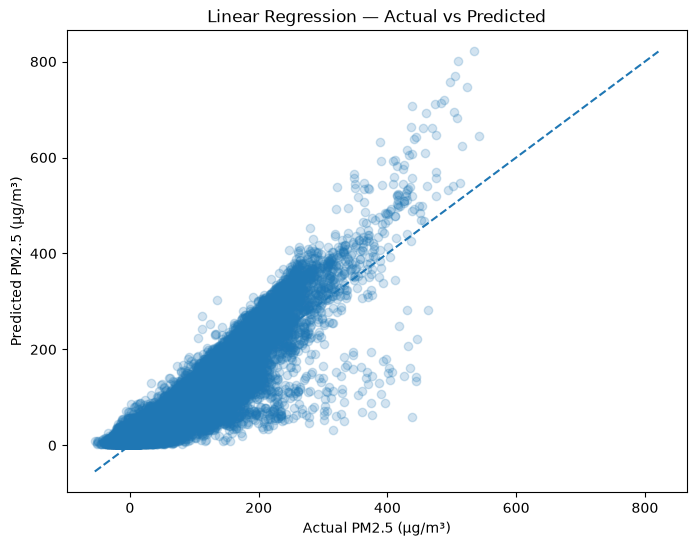

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_pollution_validation_pred,
    y_validation_common_pollution,
    alpha=0.2
)

min_value = min(
    y_pollution_validation_pred.min(),
    y_validation_common_pollution.min()
)

max_value = max(
    y_pollution_validation_pred.max(),
    y_validation_common_pollution.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)
plt.xlabel("Actual PM2.5 (µg/m³)")
plt.ylabel("Predicted PM2.5 (µg/m³)")
plt.title("Linear Regression — Actual vs Predicted")
plt.show()

Improvement thanks to the pollution data:

In [25]:
rmse_improvement = (
    (rmse_weather_common - rmse_pollution_common)
    / rmse_weather_common
    * 100
)

mae_improvement = (
    (mae_weather_common - mae_pollution_common)
    / mae_weather_common
    * 100
)

print("RMSE improvement:", rmse_improvement, "%")
print("MAE improvement:", mae_improvement, "%")
print(
    "R² improvement:",
    r2_pollution_common - r2_weather_common
)

RMSE improvement: 49.30142656074795 %
MAE improvement: 54.63276252084128 %
R² improvement: 0.46582012564619213


We can see that with the same dataset, the model with pollution data has superior performances.